In [17]:
import numpy as np
import matplotlib.pyplot as plt
from wave_optics import (
    visualize,
    visualize_grid,
    asm,
    fresnel_tf,
    fraunhofer,
    mean_squared_error,
    propagation_sanity_check,
)

In [18]:
Nx = 512
Ny = 512

dx = 2e-6
dy = 2e-6

wavelength = 532e-9

ax = 100e-6
ay = 100e-6

x = (np.arange(Nx) - Nx // 2) * dx
y = (np.arange(Ny) - Ny // 2) * dy

X, Y = np.meshgrid(x, y)

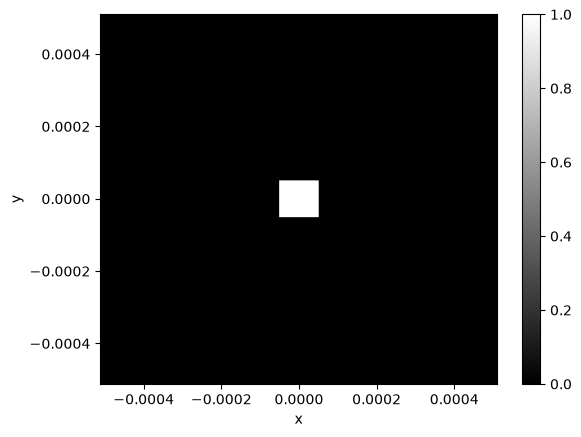

In [19]:
U0 = ((np.abs(X) <= ax / 2) & (np.abs(Y) <= ay / 2)).astype(float)
plt.imshow(
    U0,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower",
    aspect="auto",
    cmap="gray",
)

plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [20]:
print(f"z_diff = {ax**2 / (wavelength)}mm")

z_list = [
    1e-3,
    10e-3,
    100e-3,
]

z_diff = 0.018796992481203006mm


In [ ]:
z = z_list[1]
propagation_sanity_check(
    U0,
    dx,
    dy,
    wavelength,
    z,
    method="asm",
    characteristic_size=100e-6,
    Uz=asm(U0, z, wavelength, dx, dy),
)


=== Input Grid ===
Nx × Ny          : 512 × 512
dx, dy           : 2.000, 2.000 um
Lx, Ly           : 1.024, 1.024 mm

--- Spatial frequency: cycles/m ---
dfx, dfy         : 9.766e+02, 9.766e+02 1/m
Nyquist fx, fy   : 2.500e+05, 2.500e+05 1/m

--- k-space: rad/m ---
dkx, dky         : 6.136e+03, 6.136e+03 rad/m
Nyquist kx, ky   : 1.571e+06, 1.571e+06 rad/m

=== Input Field Support ===
field width x     : 0.102 mm
field width y     : 0.102 mm
x occupancy       : 10.0%
y occupancy       : 10.0%
left / right      : 0.462 / 0.460 mm
bottom / top      : 0.462 / 0.460 mm

=== Propagation ===
method            : asm
wavelength        : 532.000 nm
z                 : 100.000 mm
characteristic D  : 100.000 um
z_diff            : 18.797 mm
z / z_diff        : 5.320
regime            : transition

=== Output Grid ===
dx_out, dy_out    : 2.000, 2.000 um
Lx_out, Ly_out    : 1.024, 1.024 mm
x half-width      : 0.512 mm
y half-width      : 0.512 mm

=== Propagated Field Support ===
field width x    

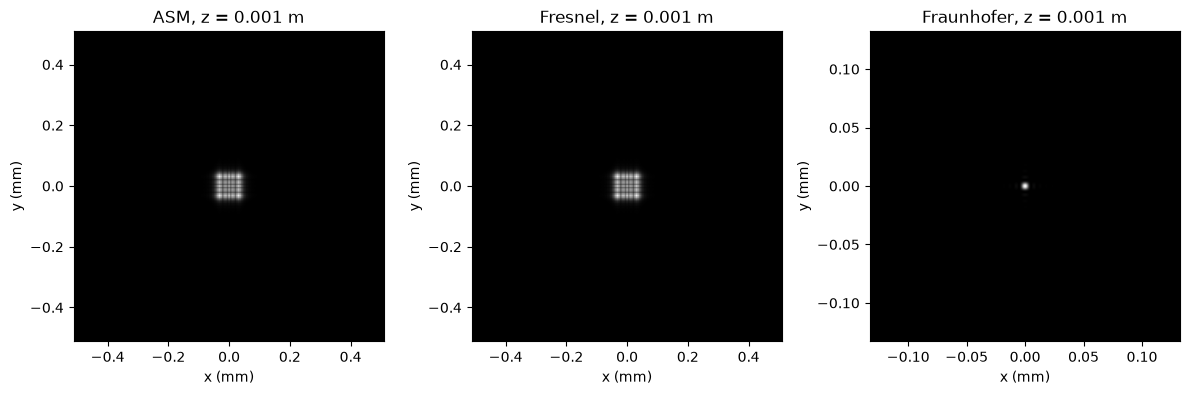

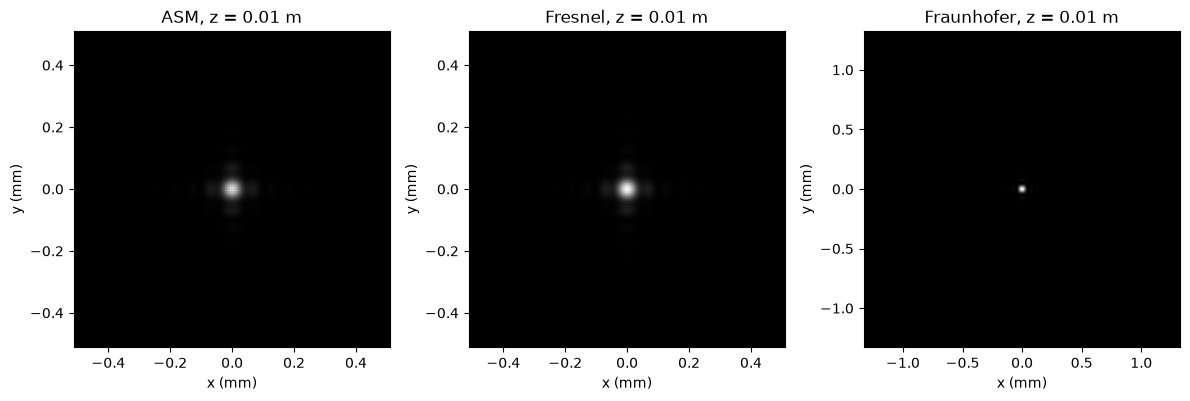

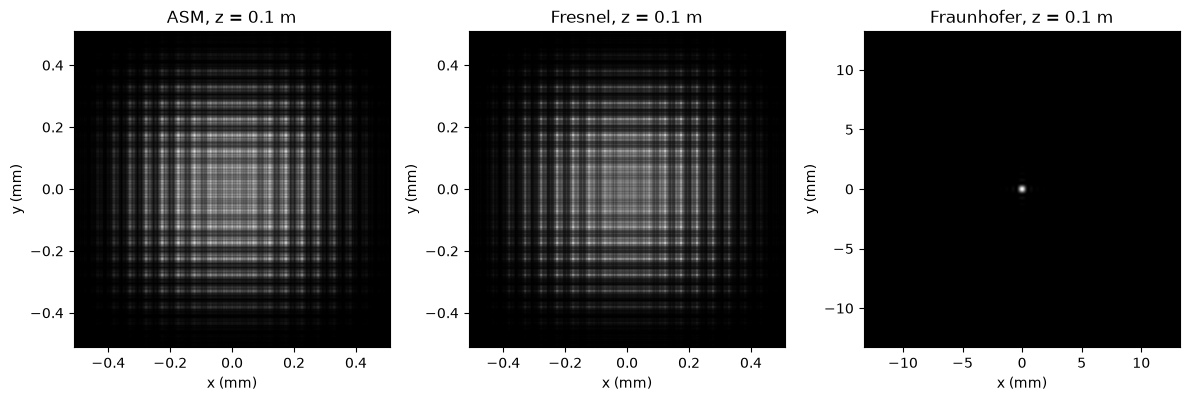

In [22]:
x_mm = x * 1000
y_mm = y * 1000


def compare_cross_section_intensity(p_asm, p_fresnel, p_fraunhofer, x, x_far):
    plt.plot(
        x * 1000,
        p_asm,
        label="ASM",
    )

    plt.plot(
        x * 1000,
        p_fresnel,
        label="Fresnel",
    )

    plt.plot(
        x_far * 1000,
        p_fraunhofer,
        label="Fraunhofer",
    )

    plt.xlabel("x(mm)")
    plt.ylabel("Intensity")
    plt.title("Compare the central cross-sections intensity")
    plt.grid()
    plt.legend()
    plt.xlim(-1, 1)
    plt.show()


error_af = []
error_ff = []
data1 = []

for z in z_list:
    U_asm = asm(U0, z, wavelength, dx, dy)
    U_fresnel = fresnel_tf(U0, z, wavelength, dx, dy)
    U_fraunhofer, x_far, y_far = fraunhofer(U0, z, wavelength, dx, dy)

    visualize_grid(
        lambda: visualize(
            U_asm,
            x_mm,
            y_mm,
            "intensity",
            f"ASM, z = {z} m",
            xlabel="x (mm)",
            ylabel="y (mm)",
        ),
        lambda: visualize(
            U_fresnel,
            x_mm,
            y_mm,
            "intensity",
            f"Fresnel, z = {z} m",
            xlabel="x (mm)",
            ylabel="y (mm)",
        ),
        lambda: visualize(
            U_fraunhofer,
            x_far * 1000,
            y_far * 1000,
            "intensity",
            f"Fraunhofer, z = {z} m",
            xlabel="x (mm)",
            ylabel="y (mm)",
        ),
        col=3,
    )

    I_asm = np.abs(U_asm) ** 2
    I_asm /= I_asm.max()

    I_fresnel = np.abs(U_fresnel) ** 2
    I_fresnel /= I_fresnel.max()

    I_fraunhofer = np.abs(U_fraunhofer) ** 2
    I_fraunhofer /= I_fraunhofer.max()

    mid = Ny // 2

    p_asm = I_asm[mid, :]
    p_fresnel = I_fresnel[mid, :]
    p_fraunhofer = I_fraunhofer[mid, :]
    data1.append([z, p_asm.copy(), p_fresnel.copy(), p_fraunhofer.copy(), x_far.copy()])

    # ASM vs Fresnel
    error_af.append(mean_squared_error(p_asm, p_fresnel))

    # Fraunhofer -> common physical coordinates
    p_far_interp = np.interp(
        x,
        x_far,
        p_fraunhofer,
        left=np.nan,
        right=np.nan,
    )

    valid = np.isfinite(p_far_interp)

    error_ff.append(
        mean_squared_error(
            p_fresnel[valid],
            p_far_interp[valid],
        )
    )

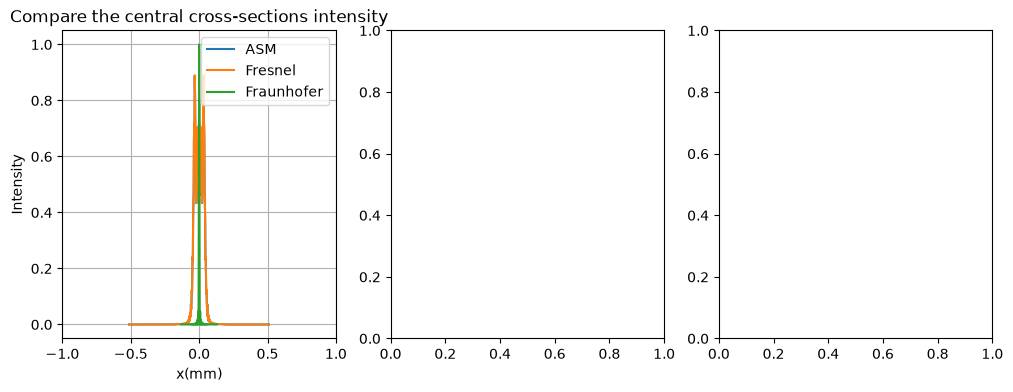

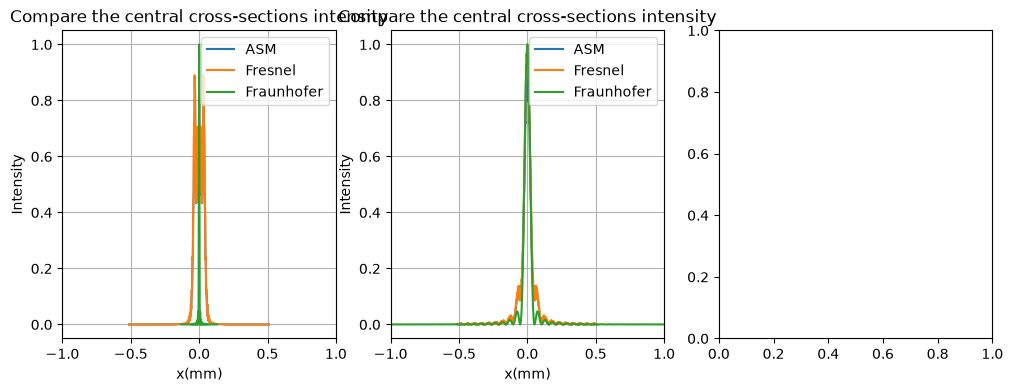

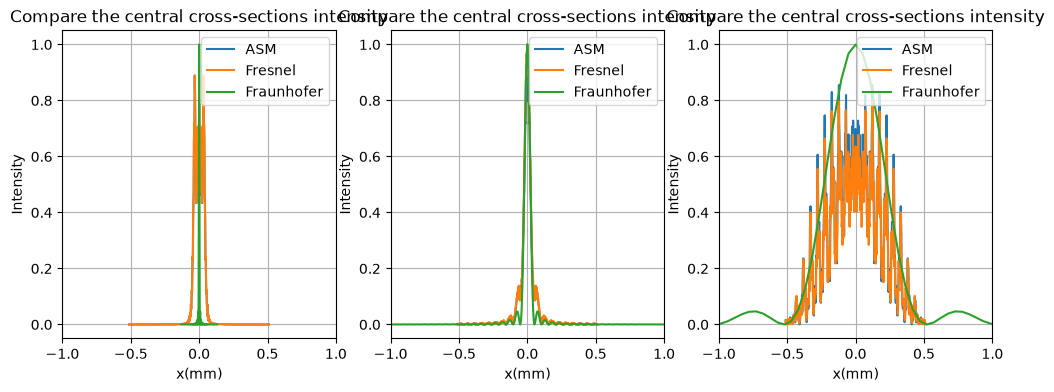

<Figure size 640x480 with 0 Axes>

In [23]:
visualize_grid(
    lambda: compare_cross_section_intensity(
        data1[0][1], data1[0][2], data1[0][3], x, data1[0][4]
    ),
    lambda: compare_cross_section_intensity(
        data1[1][1], data1[1][2], data1[1][3], x, data1[1][4]
    ),
    lambda: compare_cross_section_intensity(
        data1[2][1], data1[2][2], data1[2][3], x, data1[2][4]
    ),
    col=3,
)

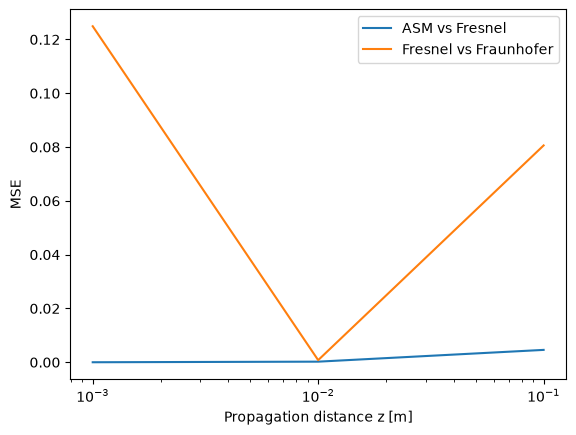

In [24]:
plt.semilogx(
    z_list,
    error_af,
    label="ASM vs Fresnel",
)

plt.semilogx(
    z_list,
    error_ff,
    label="Fresnel vs Fraunhofer",
)

plt.xlabel("Propagation distance z [m]")
plt.ylabel("MSE")
plt.legend()
plt.show()